# WiLoR multi-view hand mesh reconstruction

Companion to `h5_explore.ipynb` (left untouched). Reuses its two on-disk
outputs:

- `extracted_2d_keypoints.json` — per-camera MediaPipe body + hand 2D
  keypoints (left/right already resolved by wrist proximity).
- `final_reconstructed_3d_keypoints.json` — DLT-triangulated 3D body skeleton
  (calibration world, Y-up), used here for the wrist anchors (ids 15/16).

For every camera / frame / hand with a MediaPipe hand detection, this notebook
runs [WiLoR](https://github.com/rolpotamias/WiLoR) (at `/home/fmalmb/CODE/WiLoR`,
also untouched) on the MediaPipe hand bounding box, lifts the resulting MANO
mesh (778 vertices) into the shared calibration-world frame using the same
`ChameleonCalibrationV1` calibration, fuses the up-to-7 per-camera meshes into
one mesh per hand per frame, anchors it to the triangulated body wrist, and
renders it with Viser alongside the body skeleton.

In [11]:
import sys, os, json, pickle, types, time
import h5py
import cv2
import numpy as np
import torch
from torch.utils.data import default_collate

H5_PATH = '/data/fmalmb/DATA/tmp/Testdata.h5'
WILOR_DIR = '/home/fmalmb/CODE/WiLoR'
if WILOR_DIR not in sys.path:
    sys.path.insert(0, WILOR_DIR)

from wilor.models import load_wilor
from wilor.datasets.vitdet_dataset import ViTDetDataset
from wilor.utils import recursive_to

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# load_wilor() hardcodes relative './mano_data/...' paths, so it must be
# called with WILOR_DIR as the working directory.
_cwd = os.getcwd()
os.chdir(WILOR_DIR)
try:
    model, model_cfg = load_wilor(
        checkpoint_path=os.path.join(WILOR_DIR, 'pretrained_models/wilor_final.ckpt'),
        cfg_path=os.path.join(WILOR_DIR, 'pretrained_models/model_config.yaml'),
    )
finally:
    os.chdir(_cwd)

model = model.to(DEVICE).eval()
MANO_FACES = np.asarray(model.mano.faces, dtype=np.int64)
print(f'WiLoR model loaded on {DEVICE}; MANO faces: {MANO_FACES.shape}')

Loading  /home/fmalmb/CODE/WiLoR/pretrained_models/wilor_final.ckpt


Lightning automatically upgraded your loaded checkpoint from v1.8.1 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint pretrained_models/wilor_final.ckpt`


WiLoR model loaded on cuda; MANO faces: (1538, 3)


In [12]:
# Load Chameleon calibration from H5 (same approach as h5_explore.ipynb).
class ChameleonCalibrationV1:
    """Stub for unpickling when calib package is not installed."""
    pass


calib_mod = types.ModuleType('calib.chameleon_calibration')
calib_mod.ChameleonCalibrationV1 = ChameleonCalibrationV1
sys.modules['calib.chameleon_calibration'] = calib_mod
sys.modules['calib'] = types.ModuleType('calib')


def build_camera_cal(intrin_vec, cam_to_world):
    cx, cy, fx, fy = intrin_vec[2], intrin_vec[3], intrin_vec[4], intrin_vec[5]
    K = np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1]], dtype=np.float64)
    dist = intrin_vec[6:14].astype(np.float64)
    return K, dist


with h5py.File(H5_PATH, 'r') as f:
    cal = pickle.loads(bytes(f['calibration/cal_pickle'][()]))
    camera_ids = sorted(f['rec'].keys())

CAMERA_CALIB = {}
CAMERA_WORLD_TRANSFORMS = {}
for i, cam_id in enumerate(camera_ids):
    K, dist = build_camera_cal(cal.intrinsics[i], cal.cam_to_world[i])
    w, h = cal.intrinsics[i][0], cal.intrinsics[i][1]
    CAMERA_CALIB[cam_id] = {'K': K, 'dist': dist, 'width': float(w), 'height': float(h)}
    CAMERA_WORLD_TRANSFORMS[cam_id] = cal.cam_to_world[i].astype(np.float64)
    print(f"  {cam_id}: fx={K[0, 0]:.1f}, fy={K[1, 1]:.1f}, cx={K[0, 2]:.1f}, cy={K[1, 2]:.1f}")

print(f'Loaded ChameleonCalibrationV1 ({cal.n_cameras} cameras, gravity={cal.gravity_world})')

  cam00: fx=2014.5, fy=2014.5, cx=1673.0, cy=918.5
  cam01: fx=1997.1, fy=1997.1, cx=1690.5, cy=956.0
  cam02: fx=1990.6, fy=1990.6, cx=1723.1, cy=937.1
  cam03: fx=2011.3, fy=2011.3, cx=1700.2, cy=926.9
  cam04: fx=1995.0, fy=1995.0, cx=1697.7, cy=953.3
  cam05: fx=2014.8, fy=2014.8, cx=1728.1, cy=950.2
  cam06: fx=2002.5, fy=2002.5, cx=1679.1, cy=964.0
Loaded ChameleonCalibrationV1 (7 cameras, gravity=[0. 1. 0.])


In [13]:
with open('extracted_2d_keypoints.json') as f:
    keypoints_2d = json.load(f)

frame_keys = sorted(keypoints_2d.keys(), key=int)
NUM_FRAMES = len(frame_keys)
N_CAMS = len(camera_ids)
HAND_SIDES = ['left_hand', 'right_hand']
SIDE_INDEX = {'left_hand': 0, 'right_hand': 1}
SIDE_IS_RIGHT = {'left_hand': 0.0, 'right_hand': 1.0}

print(f'{NUM_FRAMES} frames, {N_CAMS} cameras: {camera_ids}')


def hand_bbox(landmarks):
    xs = np.array([lm['x'] for lm in landmarks], dtype=np.float32)
    ys = np.array([lm['y'] for lm in landmarks], dtype=np.float32)
    return np.array([xs.min(), ys.min(), xs.max(), ys.max()], dtype=np.float32)


def hand_confidence(landmarks):
    return float(np.mean([lm['confidence'] for lm in landmarks]))


def decode_frame(h5file, cam_id, frame_key):
    jpeg = h5file[f'rec/{cam_id}/frames/{frame_key}/color'][()]
    return cv2.imdecode(np.frombuffer(jpeg, dtype=np.uint8), cv2.IMREAD_COLOR)


def hand_boxes_for(entry):
    """Return (boxes, rights, sides) for the non-empty hand detections in a cam/frame entry."""
    boxes, rights, sides = [], [], []
    for side in HAND_SIDES:
        lms = entry[side]
        if len(lms) == 21:
            boxes.append(hand_bbox(lms))
            rights.append(SIDE_IS_RIGHT[side])
            sides.append(side)
    return boxes, rights, sides

128 frames, 7 cameras: ['cam00', 'cam01', 'cam02', 'cam03', 'cam04', 'cam05', 'cam06']


In [14]:
RESCALE_FACTOR = 2.0


def run_wilor_on_image(img_bgr, boxes, rights, cam_id):
    """Run WiLoR on one or more hand crops from a single camera image.

    `boxes` is (N,4) xyxy pixel coordinates, `rights` is (N,) with 1.0 = right
    hand / 0.0 = left hand. Returns a list of dicts with `verts_cam` (778,3)
    and `wrist_cam` (3,) in this camera's 3D frame, computed with the
    calibrated focal length / principal point instead of WiLoR's
    `cam_crop_to_full` (which assumes an approximate focal length and an
    image-centered principal point).

    `box_center` (used below) is in raw (distorted) pixel coordinates, so an
    ideal pinhole projection of `verts_cam`/`wrist_cam` through `K` lands at
    the detected pixel location in the *raw* image -- when reprojecting for
    visualization/sanity-checks, use `dist=None` (no distortion), not the
    camera's real distortion coefficients.
    """
    dataset = ViTDetDataset(model_cfg, img_bgr, boxes, rights, rescale_factor=RESCALE_FACTOR)
    batch = default_collate([dataset[i] for i in range(len(dataset))])
    batch = recursive_to(batch, DEVICE)

    with torch.no_grad():
        out = model(batch)

    pred_cam = out['pred_cam'].clone()
    pred_cam[:, 1] = (2 * batch['right'] - 1) * pred_cam[:, 1]

    box_center = batch['box_center'].float()
    box_size = batch['box_size'].float()
    K = CAMERA_CALIB[cam_id]['K']
    fx, cx, cy = float(K[0, 0]), float(K[0, 2]), float(K[1, 2])

    bs = box_size * pred_cam[:, 0] + 1e-9
    tz = 2 * fx / bs
    tx = 2 * (box_center[:, 0] - cx) / bs + pred_cam[:, 1]
    ty = 2 * (box_center[:, 1] - cy) / bs + pred_cam[:, 2]
    cam_t = torch.stack([tx, ty, tz], dim=-1).detach().cpu().numpy()

    results = []
    for n in range(len(dataset)):
        is_right = float(batch['right'][n].cpu().numpy())
        factor = 2 * is_right - 1
        verts = out['pred_vertices'][n].detach().cpu().numpy().astype(np.float32).copy()
        kpts = out['pred_keypoints_3d'][n].detach().cpu().numpy().astype(np.float32).copy()
        verts[:, 0] *= factor
        kpts[:, 0] *= factor
        results.append({
            'verts_cam': verts + cam_t[n],
            'wrist_cam': kpts[0] + cam_t[n],
            'is_right': is_right,
        })
    return results

In [15]:
TEST_FRAME = frame_keys[0]

print(f'Sanity check on frame {TEST_FRAME}: wrist reprojection error vs MediaPipe (pixels)')
with h5py.File(H5_PATH, 'r') as f5:
    for cam_id in camera_ids:
        entry = keypoints_2d[TEST_FRAME][cam_id]
        boxes, rights, sides = hand_boxes_for(entry)
        if not boxes:
            continue
        img = decode_frame(f5, cam_id, TEST_FRAME)
        results = run_wilor_on_image(img, np.stack(boxes), np.array(rights, dtype=np.float32), cam_id)
        K = CAMERA_CALIB[cam_id]['K']
        for res, side in zip(results, sides):
            # No distortion here -- see run_wilor_on_image docstring.
            proj, _ = cv2.projectPoints(res['wrist_cam'].reshape(1, 1, 3), np.zeros(3), np.zeros(3), K, None)
            mp_xy = np.array([entry[side][0]['x'], entry[side][0]['y']])
            err = np.linalg.norm(proj.reshape(2) - mp_xy)
            print(f'  {cam_id} {side}: {err:5.1f}px')

Sanity check on frame 000000: wrist reprojection error vs MediaPipe (pixels)
  cam00 left_hand:   2.1px
  cam00 right_hand:   2.3px
  cam01 right_hand:  28.2px
  cam02 left_hand:   1.0px
  cam02 right_hand:   6.6px
  cam03 left_hand:  11.1px
  cam03 right_hand:  11.7px
  cam04 left_hand:   8.6px
  cam04 right_hand:   9.0px
  cam05 left_hand:  11.9px
  cam05 right_hand:  20.2px
  cam06 left_hand:   4.9px
  cam06 right_hand:  11.7px


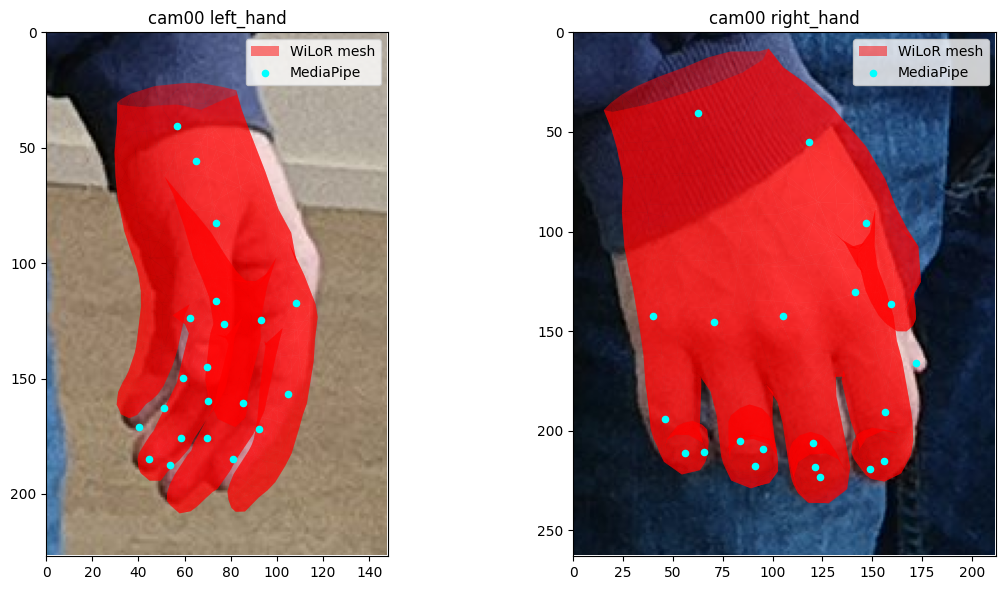

In [16]:
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection

VIS_CAM = 'cam00'
with h5py.File(H5_PATH, 'r') as f5:
    img = decode_frame(f5, VIS_CAM, TEST_FRAME)

entry = keypoints_2d[TEST_FRAME][VIS_CAM]
boxes, rights, sides = hand_boxes_for(entry)
results = run_wilor_on_image(img, np.stack(boxes), np.array(rights, dtype=np.float32), VIS_CAM)
K = CAMERA_CALIB[VIS_CAM]['K']

fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 6))
if len(results) == 1:
    axes = [axes]
for ax, res, side, box in zip(axes, results, sides, boxes):
    # No distortion here -- see run_wilor_on_image docstring.
    proj, _ = cv2.projectPoints(res['verts_cam'], np.zeros(3), np.zeros(3), K, None)
    proj = proj.reshape(-1, 2)
    x0, y0, x1, y1 = box.astype(int)
    pad = 40
    x0p, y0p = max(0, x0 - pad), max(0, y0 - pad)
    crop = cv2.cvtColor(img[y0p:y1 + pad, x0p:x1 + pad], cv2.COLOR_BGR2RGB)
    ax.imshow(crop)
    faces_xy = proj[MANO_FACES] - np.array([x0p, y0p])
    mesh_poly = PolyCollection(faces_xy, facecolor='red', edgecolor='none', alpha=0.5, label='WiLoR mesh')
    ax.add_collection(mesh_poly)
    mp_pts = np.array([[lm['x'], lm['y']] for lm in entry[side]])
    ax.scatter(mp_pts[:, 0] - x0p, mp_pts[:, 1] - y0p, s=20, c='cyan', label='MediaPipe')
    ax.set_title(f'{VIS_CAM} {side}')
    ax.set_xlim(0, crop.shape[1])
    ax.set_ylim(crop.shape[0], 0)
    ax.legend()
plt.tight_layout()
plt.savefig('wilor_sanity_check.png', dpi=100)
plt.show()

In [17]:
OUT_RAW_NPZ = 'wilor_hand_meshes_raw.npz'

verts_cam_all = np.zeros((NUM_FRAMES, N_CAMS, 2, 778, 3), dtype=np.float32)
wrist_cam_all = np.zeros((NUM_FRAMES, N_CAMS, 2, 3), dtype=np.float32)
valid_all = np.zeros((NUM_FRAMES, N_CAMS, 2), dtype=bool)
weight_all = np.zeros((NUM_FRAMES, N_CAMS, 2), dtype=np.float32)

t0 = time.time()
with h5py.File(H5_PATH, 'r') as f5:
    for fi, frame_key in enumerate(frame_keys):
        for ci, cam_id in enumerate(camera_ids):
            entry = keypoints_2d[frame_key][cam_id]
            boxes, rights, sides = hand_boxes_for(entry)
            if not boxes:
                continue
            img = decode_frame(f5, cam_id, frame_key)
            results = run_wilor_on_image(img, np.stack(boxes), np.array(rights, dtype=np.float32), cam_id)
            for res, side in zip(results, sides):
                si = SIDE_INDEX[side]
                verts_cam_all[fi, ci, si] = res['verts_cam']
                wrist_cam_all[fi, ci, si] = res['wrist_cam']
                valid_all[fi, ci, si] = True
                weight_all[fi, ci, si] = hand_confidence(entry[side])
        if (fi + 1) % 16 == 0 or (fi + 1) == NUM_FRAMES:
            print(f'  {fi + 1}/{NUM_FRAMES} frames ({time.time() - t0:.1f}s)')

np.savez_compressed(
    OUT_RAW_NPZ,
    verts_cam=verts_cam_all,
    wrist_cam=wrist_cam_all,
    valid=valid_all,
    weight=weight_all,
    mano_faces=MANO_FACES,
    frame_keys=np.array(frame_keys),
    camera_ids=np.array(camera_ids),
)
print(f'Saved {OUT_RAW_NPZ}')
print('Coverage (valid detections) per camera/side:')
for ci, cam_id in enumerate(camera_ids):
    print(f"  {cam_id}: left={valid_all[:, ci, 0].sum():3d}/{NUM_FRAMES}  right={valid_all[:, ci, 1].sum():3d}/{NUM_FRAMES}")

  16/128 frames (6.7s)
  32/128 frames (12.9s)
  48/128 frames (20.2s)
  64/128 frames (26.7s)
  80/128 frames (32.9s)
  96/128 frames (41.1s)
  112/128 frames (46.7s)
  128/128 frames (52.9s)
Saved wilor_hand_meshes_raw.npz
Coverage (valid detections) per camera/side:
  cam00: left=108/128  right=101/128
  cam01: left= 29/128  right=124/128
  cam02: left=117/128  right=128/128
  cam03: left=125/128  right=128/128
  cam04: left=127/128  right=128/128
  cam05: left=128/128  right=128/128
  cam06: left=123/128  right=128/128


In [18]:
with open('final_reconstructed_3d_keypoints.json') as f:
    body_3d = json.load(f)

BODY_WRIST_ID = {'left_hand': '15', 'right_hand': '16'}
OUTLIER_FACTOR = 1.5
# WiLoR's per-camera estimate of the hand's world-frame orientation can be bimodal: a
# near edge-on view of the hand is ambiguous, so roughly half the cameras agree on one
# orientation and half on another ~90 degrees apart (e.g. right hand around frame 61).
# A median over all cameras flips wholesale to the other cluster whenever the vote
# count tips (e.g. one camera switches clusters), causing a one-frame mesh "flip".
# Anchoring outlier rejection to the *previous frame's* fused result instead of the
# current frame's median keeps the fusion locked onto whichever cluster it was
# already tracking, giving a temporally smooth orientation.
TEMPORAL_THRESHOLD = 0.08  # meters; max drift of rel_verts from the previous frame's fused result

left_verts = np.zeros((NUM_FRAMES, 778, 3), dtype=np.float32)
right_verts = np.zeros((NUM_FRAMES, 778, 3), dtype=np.float32)
left_valid = np.zeros(NUM_FRAMES, dtype=bool)
right_valid = np.zeros(NUM_FRAMES, dtype=bool)
OUT_VERTS = {'left_hand': left_verts, 'right_hand': right_verts}
OUT_VALID = {'left_hand': left_valid, 'right_hand': right_valid}

prev_merged_rel = {side: None for side in HAND_SIDES}

for fi, frame_key in enumerate(frame_keys):
    for side in HAND_SIDES:
        si = SIDE_INDEX[side]
        cams = [ci for ci in range(N_CAMS) if valid_all[fi, ci, si]]
        if not cams:
            prev_merged_rel[side] = None
            continue

        rel_list, wrist_world_list, weights = [], [], []
        for ci in cams:
            T_cw = CAMERA_WORLD_TRANSFORMS[camera_ids[ci]]
            R, t = T_cw[:3, :3], T_cw[:3, 3]
            verts_world = (R @ verts_cam_all[fi, ci, si].T).T + t
            wrist_world = R @ wrist_cam_all[fi, ci, si] + t
            rel_list.append(verts_world - wrist_world)
            wrist_world_list.append(wrist_world)
            weights.append(weight_all[fi, ci, si])

        rel_arr = np.stack(rel_list)
        weights = np.array(weights, dtype=np.float64)
        wrist_world_arr = np.stack(wrist_world_list)

        keep = np.ones(len(cams), dtype=bool)
        if prev_merged_rel[side] is not None:
            dev_prev = np.mean(np.linalg.norm(rel_arr - prev_merged_rel[side], axis=-1), axis=-1)
            temporal_keep = dev_prev <= TEMPORAL_THRESHOLD
            if temporal_keep.any():
                keep = temporal_keep

        rel_kept, weights_kept, wrist_kept = rel_arr[keep], weights[keep], wrist_world_arr[keep]
        if keep.sum() > 2:
            median_rel = np.median(rel_kept, axis=0)
            dev = np.mean(np.linalg.norm(rel_kept - median_rel, axis=-1), axis=-1)
            keep2 = dev <= OUTLIER_FACTOR * np.median(dev)
            if keep2.any():
                rel_kept, weights_kept, wrist_kept = rel_kept[keep2], weights_kept[keep2], wrist_kept[keep2]

        merged_rel = np.tensordot(weights_kept / weights_kept.sum(), rel_kept, axes=(0, 0))
        prev_merged_rel[side] = merged_rel

        bid = BODY_WRIST_ID[side]
        if bid in body_3d.get(frame_key, {}):
            j = body_3d[frame_key][bid]
            wrist_anchor = np.array([j['X'], j['Y'], j['Z']], dtype=np.float64)
        else:
            wrist_anchor = wrist_kept.mean(axis=0)

        OUT_VERTS[side][fi] = (merged_rel + wrist_anchor).astype(np.float32)
        OUT_VALID[side][fi] = True

np.savez_compressed(
    'final_hand_meshes_wilor.npz',
    left_verts=left_verts,
    right_verts=right_verts,
    left_valid=left_valid,
    right_valid=right_valid,
    mano_faces=MANO_FACES,
    frame_keys=np.array(frame_keys),
)
print('Saved final_hand_meshes_wilor.npz')
print(f'left valid: {left_valid.sum()}/{NUM_FRAMES}  right valid: {right_valid.sum()}/{NUM_FRAMES}')

fi0 = int(np.argmax(left_valid))
wrist0 = body_3d[frame_keys[fi0]]['15']
wrist0 = np.array([wrist0['X'], wrist0['Y'], wrist0['Z']])
print(f'sanity: frame {frame_keys[fi0]} left-hand mesh centroid is '
      f'{np.linalg.norm(left_verts[fi0].mean(axis=0) - wrist0):.3f} m from the body wrist anchor '
      f'(should be roughly hand-sized, ~0.05-0.15 m)')

Saved final_hand_meshes_wilor.npz
left valid: 128/128  right valid: 128/128
sanity: frame 000000 left-hand mesh centroid is 0.092 m from the body wrist anchor (should be roughly hand-sized, ~0.05-0.15 m)


In [19]:
import viser
from viser import transforms as tf

# Calibration world is Y-up; Viser uses Z-up. Flip world Y so the figure is upright.
R_WORLD_TO_VISER = np.array([
    [1.0, 0.0, 0.0],
    [0.0, 0.0, 1.0],
    [0.0, -1.0, 0.0],
], dtype=np.float64)
FRUSTUM_SCALE_BASE = 0.10
FRUSTUM_SCALE_PER_M = 0.03

POSE_CONNECTIONS = [
    (11, 12), (11, 23), (12, 24), (23, 24),
    (11, 13), (13, 15),
    (12, 14), (14, 16),
    (23, 25), (25, 27), (27, 29), (27, 31), (29, 31),
    (24, 26), (26, 28), (28, 30), (28, 32), (30, 32),
    (0, 1), (1, 2), (2, 3), (0, 4), (4, 5), (5, 6), (3, 7), (6, 8),
    (9, 10),
]
POSE_HAND_JOINTS = {17, 18, 19, 20, 21, 22}


def skeleton_origin(joints_dict):
    """Pelvis midpoint, else mean of all body joints."""
    hip_pts = []
    for hip_id in (23, 24):
        key = str(hip_id)
        if key in joints_dict:
            hip_pts.append([joints_dict[key]['X'], joints_dict[key]['Y'], joints_dict[key]['Z']])
    if len(hip_pts) == 2:
        return np.mean(hip_pts, axis=0)
    body_pts = [[v['X'], v['Y'], v['Z']] for k, v in joints_dict.items() if int(k) < 100]
    if body_pts:
        return np.mean(body_pts, axis=0)
    return np.zeros(3, dtype=np.float64)


def world_to_viser_point(p_world, origin_world):
    return R_WORLD_TO_VISER @ (np.asarray(p_world, dtype=np.float64) - origin_world)


def world_to_viser_pose(T_cw, origin_world):
    T = np.asarray(T_cw, dtype=np.float64).copy()
    T[:3, 3] = R_WORLD_TO_VISER @ (T[:3, 3] - origin_world)
    T[:3, :3] = R_WORLD_TO_VISER @ T[:3, :3]
    wxyz = tf.SO3.from_matrix(T[:3, :3]).wxyz
    return wxyz.astype(np.float64), T[:3, 3].astype(np.float64)


def body_joint_coords(joints_dict, origin_world):
    out = {}
    for j_id, v in joints_dict.items():
        jid = int(j_id)
        if jid >= 100 or jid in POSE_HAND_JOINTS:
            continue
        out[jid] = world_to_viser_point([v['X'], v['Y'], v['Z']], origin_world).astype(np.float32)
    return out


def add_bones(server, name, joint_coords, connections, color):
    segs = []
    for a, b in connections:
        if a in joint_coords and b in joint_coords:
            segs.append([joint_coords[a], joint_coords[b]])
    if segs:
        server.scene.add_line_segments(
            name=name,
            points=np.array(segs, dtype=np.float32),
            colors=np.array(color, dtype=np.uint8),
            line_width=2.0,
        )


def apply_fov(server, fov_deg):
    fov_rad = float(np.deg2rad(fov_deg))
    server.initial_camera.fov = fov_rad
    for client in server.get_clients().values():
        client.camera.fov = fov_rad


def verts_to_viser(verts_world, origin_world):
    return (R_WORLD_TO_VISER @ (verts_world - origin_world).T).T


ORIGIN_WORLD = skeleton_origin(body_3d[frame_keys[0]])

# The left-hand mesh is produced by mirroring a right-hand MANO output
# (verts[:, 0] *= -1), which reverses the chirality of the mesh and therefore
# the winding order of MANO_FACES -- with the original face order the
# left-hand mesh's normals point inward. Reversing each triangle's vertex
# order restores outward-facing normals.
MANO_FACES_MIRRORED = MANO_FACES[:, [0, 2, 1]]

HAND_MESH_SPECS = [
    ('left_hand', left_verts, left_valid, MANO_FACES_MIRRORED, (180, 220, 255), '/hands/left_wilor'),
    ('right_hand', right_verts, right_valid, MANO_FACES, (255, 200, 170), '/hands/right_wilor'),
]


def setup_cameras(server):
    for cam_id, T_cw in CAMERA_WORLD_TRANSFORMS.items():
        calib = CAMERA_CALIB[cam_id]
        K = calib['K']
        fov = 2.0 * np.arctan(calib['height'] / (2.0 * K[1, 1]))
        aspect = float(calib['width'] / calib['height'])
        wxyz, position = world_to_viser_pose(T_cw, ORIGIN_WORLD)
        dist = float(np.linalg.norm(position))
        frustum_scale = float(np.clip(FRUSTUM_SCALE_BASE + FRUSTUM_SCALE_PER_M * dist, 0.08, 0.16))
        server.scene.add_camera_frustum(
            name=f'/cameras/{cam_id}',
            fov=float(fov),
            aspect=aspect,
            scale=frustum_scale,
            line_width=0.5,
            color=(80, 160, 255),
            wxyz=wxyz,
            position=position,
        )
        server.scene.add_frame(
            name=f'/cameras/{cam_id}/axis',
            axes_length=0.08,
            axes_radius=0.004,
            wxyz=wxyz,
            position=position,
        )


def main():
    server = viser.ViserServer()
    running = True
    mesh_handles = {}
    try:
        server.scene.set_up_direction('+z')
        server.scene.configure_environment_map(hdri=None, background=False, environment_intensity=0.6)
        server.gui.configure_theme(dark_mode=True)
        server.scene.set_background_image(np.zeros((8, 8, 3), dtype=np.uint8))

        setup_cameras(server)

        server.initial_camera.position = (2.5, 2.0, 1.6)
        server.initial_camera.look_at = (0.0, 0.0, 0.9)
        server.initial_camera.up = (0.0, 0.0, 1.0)

        print('Viser: open the URL shown above')
        print(f'Origin offset (calibration world): {ORIGIN_WORLD}')

        play_button = server.gui.add_button('Play / Pause')
        stop_button = server.gui.add_button('Stop viewer')
        speed_slider = server.gui.add_slider('Playback Speed (FPS)', min=1, max=60, step=1, initial_value=15)
        frame_slider = server.gui.add_slider('Timeline Frame', min=0, max=NUM_FRAMES - 1, step=1, initial_value=0)
        fov_slider = server.gui.add_slider('Camera FOV (deg)', min=20.0, max=120.0, step=1.0, initial_value=75.0)
        apply_fov(server, fov_slider.value)
        is_playing = False

        @play_button.on_click
        def _(_) -> None:
            nonlocal is_playing
            is_playing = not is_playing

        @stop_button.on_click
        def _stop(_) -> None:
            nonlocal running
            running = False

        @fov_slider.on_update
        def _fov(_) -> None:
            apply_fov(server, fov_slider.value)

        current_idx = 0
        while running:
            if not is_playing:
                current_idx = frame_slider.value
            f_key = frame_keys[current_idx]

            joint_coords = body_joint_coords(body_3d[f_key], ORIGIN_WORLD)
            if joint_coords:
                ids = sorted(joint_coords)
                pts = np.stack([joint_coords[i] for i in ids]).astype(np.float32)
                server.scene.add_point_cloud(
                    name='/skeleton/joints',
                    points=pts,
                    colors=np.full((len(ids), 3), 220, dtype=np.uint8),
                    point_size=0.005,
                )
                add_bones(server, '/skeleton/body', joint_coords, POSE_CONNECTIONS, (0, 255, 120))

            for side, verts, valid, faces, color, name in HAND_MESH_SPECS:
                if valid[current_idx]:
                    v = verts_to_viser(verts[current_idx], ORIGIN_WORLD).astype(np.float32)
                    mesh_handles[name] = server.scene.add_mesh_simple(
                        name=name, vertices=v, faces=faces, color=color, opacity=0.9,
                    )
                elif name in mesh_handles:
                    mesh_handles[name].visible = False

            if is_playing:
                current_idx = (current_idx + 1) % NUM_FRAMES
                frame_slider.value = current_idx
                time.sleep(1.0 / speed_slider.value)
            else:
                time.sleep(0.05)
    except KeyboardInterrupt:
        print('Viewer interrupted.')
    finally:
        server.stop()
        print('Viser stopped.')


main()

╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

Viser: open the URL shown above
Origin offset (calibration world): [0.00249324 1.57398606 1.68523459]


(viser) Connection opened (0, 1 total), 86 persistent messages

(viser) Connection closed (0, 0 total)

(viser) Server stopped

Viser stopped.


In [ ]:
# Optional: stop a Viser server if the viewer cell did not shut down cleanly.
# Re-run the viewer cell (cell above) after stopping any old server.
print('Use Stop viewer in Viser GUI, or interrupt the cell, to stop the viewer.')